<a href="https://colab.research.google.com/github/Jupiterian/ML-Learning-Portfolio/blob/main/Linear%20Algebra/Ridge_and_Lasso_Regressions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ridge Regressions and Lasso Regressions
The following notebook covers a basic algorithms for Ridge Regressions and Lasso Regressions.

Both regressions are used to prevent tradiitional regressions from overfitting. They work by introducing a penalty to the regression.

Ridge regressions uses L2-regularization, by adding a penalty in L2. Ridge regressions are most useful for overfitting while preserving the features.
Lasso regressions uses L1-regularization, by adding a penalty in L1. Lasso regressions typically result in sparse solutions, which is often prefered for things like feature selection.

## Mathematical Derivations

In a typical least squares regression problem, to find the best line or curve to go through all the points you do the following:
<br>
First you set it up into a linear algebra problem with matrix $A$ with the features, and then have your weights in $x$, and finally $b$ with the actual observed points.
Since $b$ is not in the column space of $A$, you proceed to use Gauss's method of projecting $b$ onto the column space, or in other words multiplying both sides by $A^T$. $$A^T Ax = A^Tb$$
<br>
However if you want to introduce a penalty to prevent something like overfitting, the equation changed. Instead of minimizing $||Ax - b||_2$ in the previous scenario you are now minimizing $$||Ax - b||_2^2 + δ^2||x||_2^2$$ or $$||Ax - b||_2^2 + δ||x||_1$$ for Ridge and Lasso regression respectively. This further simplifies to $$(A^TA + δ^2I)x = A^Tb$$ for Ridge regressions. Lasso regressions cannot be simplfied further as the L1 norm is not differentiable at 0.

## Modules

In [41]:
import numpy as np
import matplotlib.pyplot as plt

## Ridge Regression
The following section explores Ridge Regressions with and without gradient descent.

### Ridge Regression without Gradient Descent

In [35]:
class RidgeRegression():
  def fit(self, A, delta, b):
    shape = A.shape
    I = np.eye(shape[1])
    self.weights = np.linalg.solve(A.T @ A + delta**2 * I, A.T @ b)
  def predict(self, A):
    return np.matmul(A, self.weights)

In [49]:
X = np.random.random([3, 1])
y = np.random.random([3, 1])
X = np.column_stack([np.ones([3,1]), X])
regression = RidgeRegression()
regression.fit(A=X, delta=0.01, b=y)
pred = regression.predict(X)

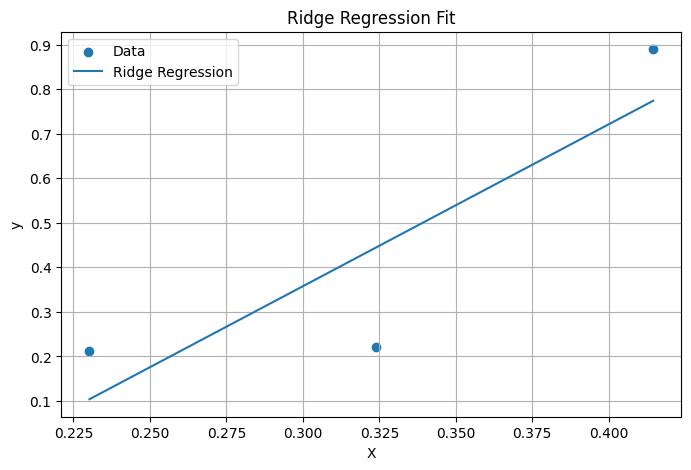

In [50]:
# Get x-values (remove bias column)
x_vals = X[:, 1]

# Sort for a clean line plot
idx = np.argsort(x_vals)

plt.figure(figsize=(8,5))

# Plot data points
plt.scatter(x_vals, y, label="Data")

# Plot Ridge prediction line
plt.plot(
    x_vals[idx],
    pred[idx],
    label="Ridge Regression"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Ridge Regression Fit")
plt.legend()
plt.grid(True)

plt.show()